In [1]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense,Conv2D, Flatten, MaxPooling2D
from keras import Sequential
from tensorflow.keras import datasets, layers, models
from keras.datasets import mnist

In [2]:
from tensorflow.keras import datasets, layers, models
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

In [3]:
# Normalize pixel values to be between 0 and 1
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255


In [4]:
# Build the CNN model
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [5]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])


In [6]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 3, 3, 64)          36928     
                                                                 
 flatten (Flatten)           (None, 576)               0

In [7]:
# Train the model
history = model.fit(train_images, train_labels, epochs=25,validation_data=(test_images, test_labels))

Epoch 1/25
1875/1875 [==============================] - 23s 12ms/step - loss: 0.1495 - accuracy: 0.9533 - val_loss: 0.0410 - val_accuracy: 0.9864
Epoch 2/25
1875/1875 [==============================] - 21s 11ms/step - loss: 0.0474 - accuracy: 0.9855 - val_loss: 0.0381 - val_accuracy: 0.9877
Epoch 3/25
1875/1875 [==============================] - 22s 12ms/step - loss: 0.0355 - accuracy: 0.9889 - val_loss: 0.0349 - val_accuracy: 0.9888
Epoch 4/25
1875/1875 [==============================] - 23s 12ms/step - loss: 0.0268 - accuracy: 0.9918 - val_loss: 0.0373 - val_accuracy: 0.9882
Epoch 5/25
1875/1875 [==============================] - 22s 12ms/step - loss: 0.0216 - accuracy: 0.9933 - val_loss: 0.0323 - val_accuracy: 0.9905
Epoch 6/25
1875/1875 [==============================] - 21s 11ms/step - loss: 0.0182 - accuracy: 0.9942 - val_loss: 0.0277 - val_accuracy: 0.9916
Epoch 7/25
1875/1875 [==============================] - 22s 12ms/step - loss: 0.0152 - accuracy: 0.9954 - val_loss: 0.0376 -

In [10]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

313/313 - 1s - loss: 0.0490 - accuracy: 0.9921 - 1s/epoch - 4ms/step

Test accuracy: 0.9921


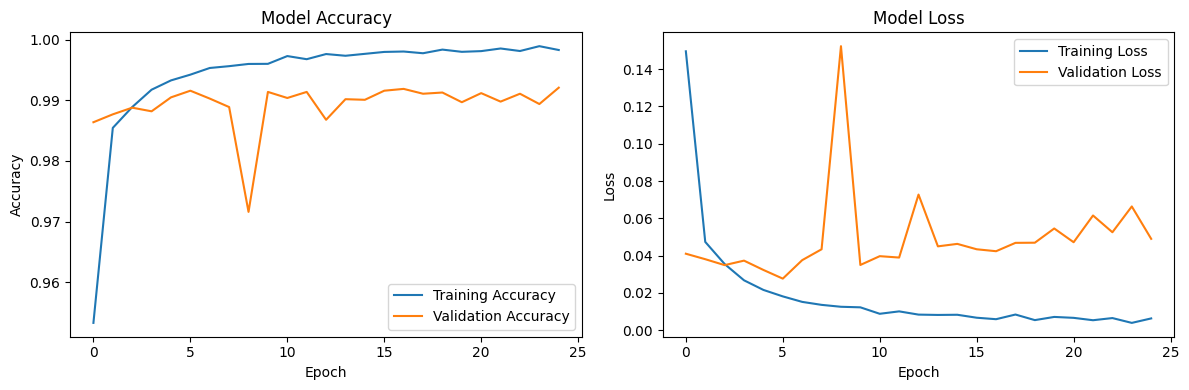

In [13]:
# Plot the training history
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Make predictions on test data
import numpy as np
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

313/313 [==============================] - 1s 4ms/step


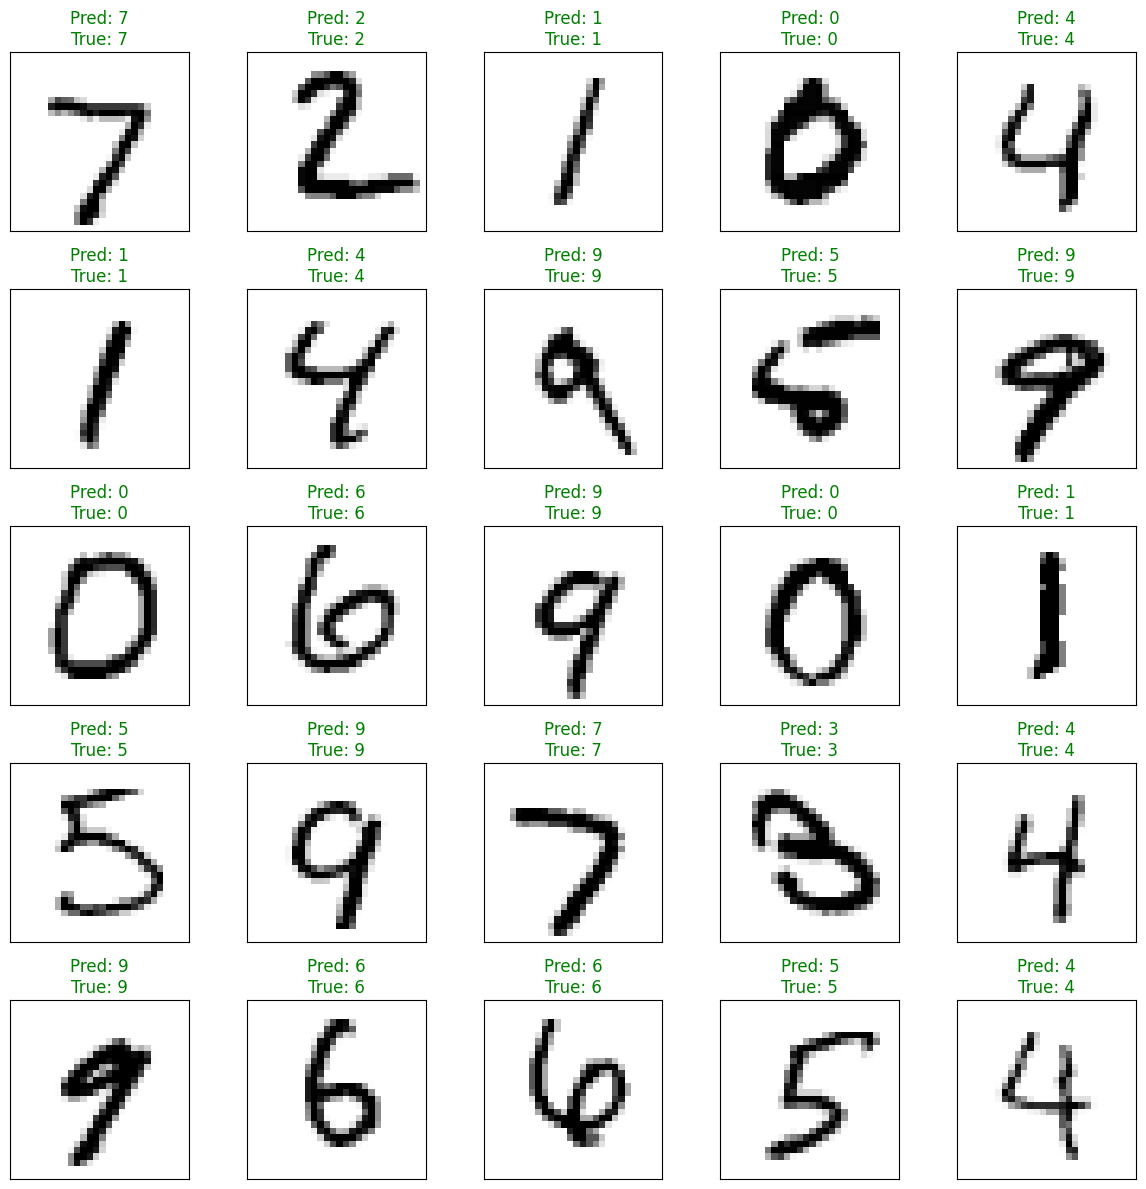

In [16]:
# Display some examples with predictions
plt.figure(figsize=(12, 12))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i].reshape(28, 28), cmap=plt.cm.binary)
    # Color the title based on whether the prediction was correct
    if predicted_classes[i] == test_labels[i]:
        color = 'green'
    else:
        color = 'red'
    plt.title(f"Pred: {predicted_classes[i]}\nTrue: {test_labels[i]}", color=color)
plt.tight_layout()
plt.show()